DATA AWAL
Jumlah baris : 26620
Jumlah SID   : 521

Setelah cleaning:
Jumlah baris : 26620
Jumlah SID   : 521

Jumlah genesis sebelum filter wilayah: 521

DATA PENELITIAN SETELAH FILTER GENESIS
Jumlah kejadian : 392

Jumlah berdasarkan zona:
zone
Utara         354
Selatan        36
Ekuatorial      2
Name: count, dtype: int64

Jumlah berdasarkan TYPE:
TYPE
D       343
L        36
S        10
<NA>      1
M         1
C         1
Name: count, dtype: Int64

Excel berhasil disimpan:
output_3_1_1\Tabel_BAB_III_3_1_1.xlsx


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11288\502178333.py:1917: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


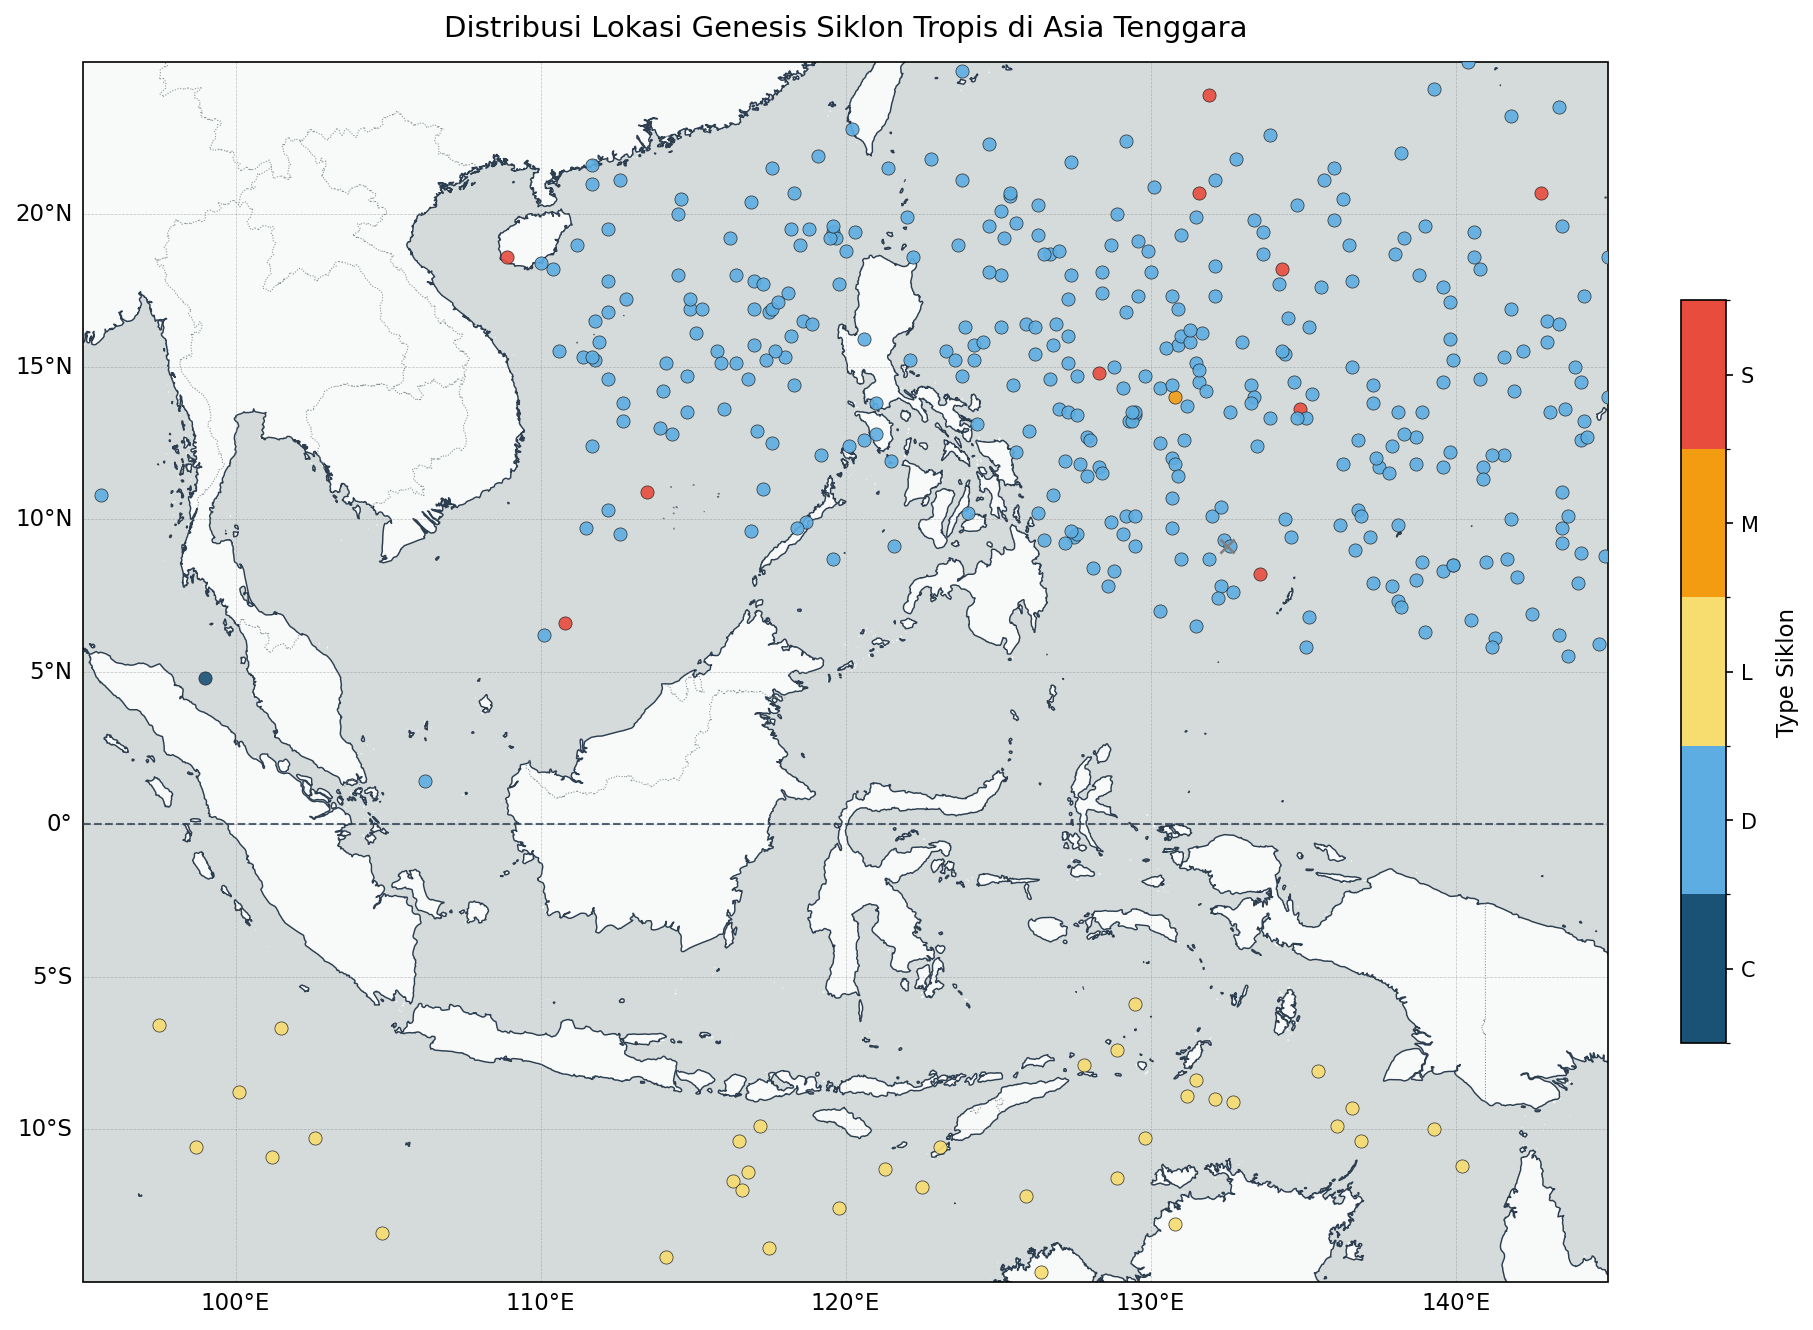


Gambar 3.1 tersimpan:
output_3_1_1\Gambar_3.1_Peta_Genesis_Type.png


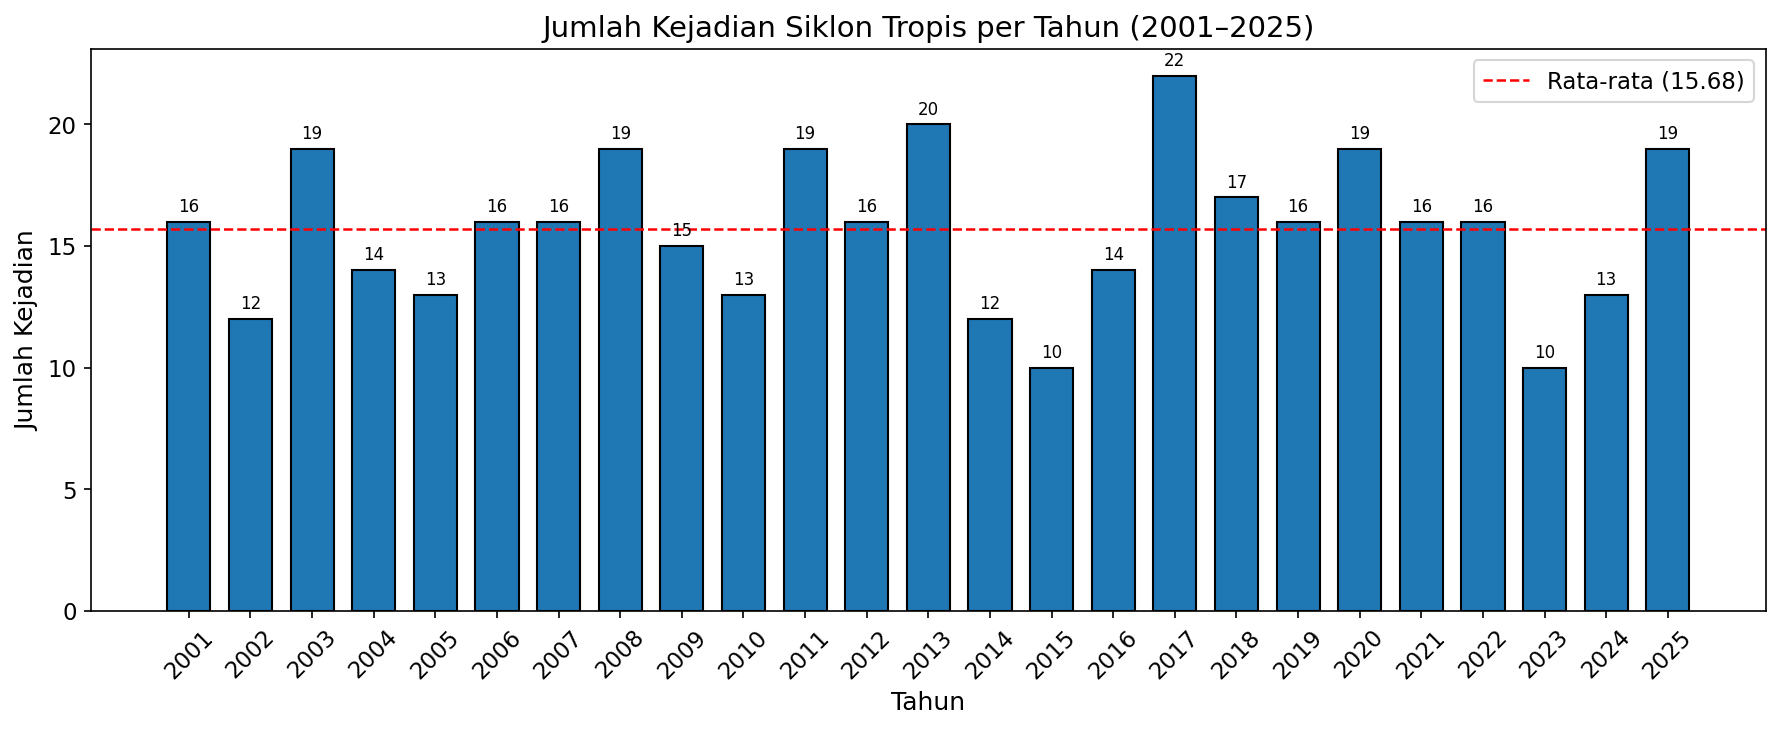

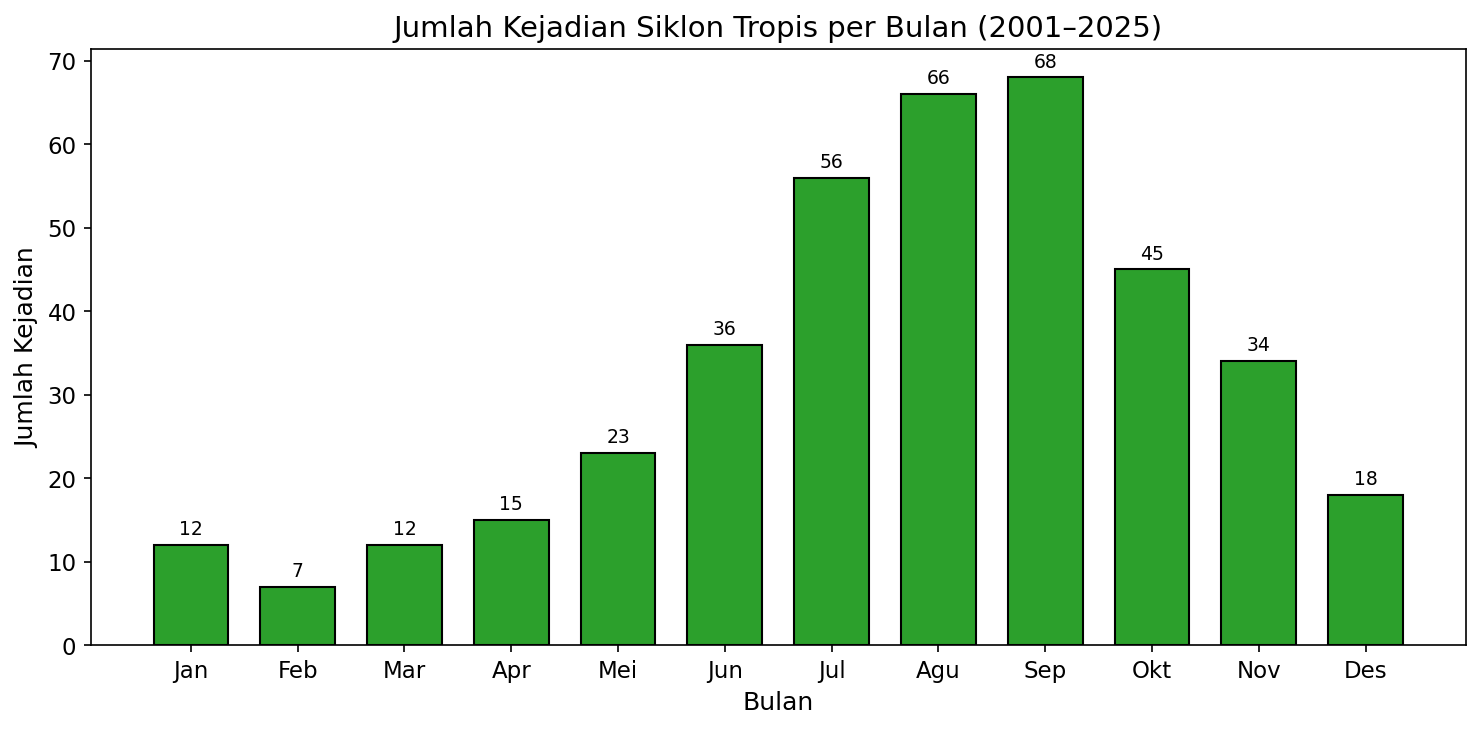

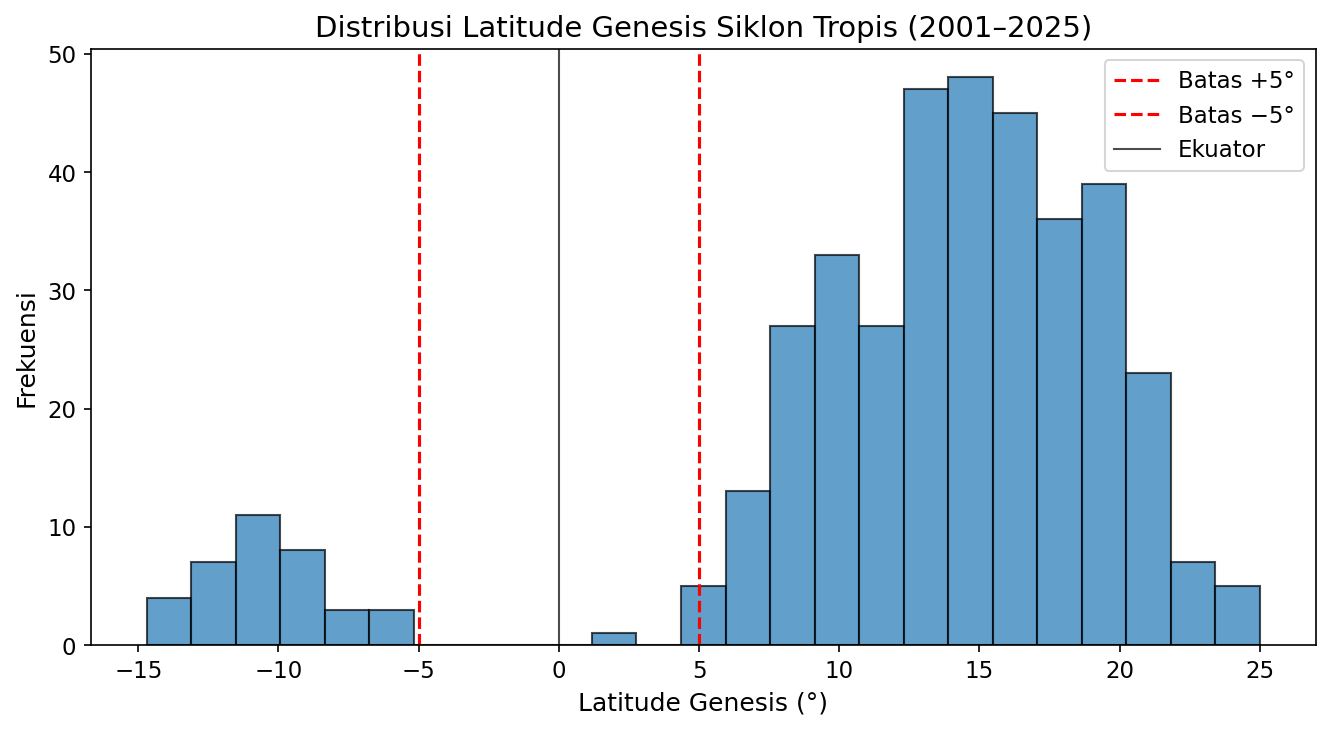


RINGKASAN FINAL 3.1.1
Total kejadian             : 392
Rata-rata per tahun        : 15.68
Tahun tertinggi            : [2017] (22 kejadian)
Tahun terendah             : [2015, 2023] (10 kejadian)
Bulan tertinggi            : September (68 kejadian)
Bulan terendah             : Februari (7 kejadian)
Periode musiman dominan    : JJA (158 kejadian; 40.31%)

TABEL 3.1
                Zona  Jumlah Kejadian  Persentase (%)
  Utara Khatulistiwa              354            90.3
          Ekuatorial                2             0.5
Selatan Khatulistiwa               36             9.2
               Total              392           100.0

DISTRIBUSI MUSIMAN
Periode                      Bulan  Jumlah Kejadian  Persentase (%)
    DJF  Desember–Januari–Februari               37            9.44
    MAM            Maret–April–Mei               50           12.76
    JJA          Juni–Juli–Agustus              158           40.31
    SON September–Oktober–November              147           37.50

D

In [3]:
# ============================================================
# BAB III - 3.1.1
# DISTRIBUSI SPASIAL DAN TEMPORAL SIKLON TROPIS
#
# Dataset:
# Siklon_Tropis_ERA5_Extracted.xlsx
#
# Domain penelitian:
# 95°BT – 145°BT
# 15°LS – 25°LU
#
# Seleksi kejadian:
# Berdasarkan posisi GENESIS
#
# Output:
# - Gambar 3.1 Peta Genesis berdasarkan TYPE
# - Gambar 3.2 Jumlah kejadian per tahun
# - Gambar 3.3 Jumlah kejadian per bulan
# - Gambar 3.4 Histogram latitude genesis
# - Tabel 3.1 Jumlah dan persentase berdasarkan zona
# - Tabel 3.2 Statistik deskriptif distribusi temporal
# ============================================================


# ============================================================
# 0. IMPORT LIBRARY
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cartopy.mpl.gridliner import (
    LONGITUDE_FORMATTER,
    LATITUDE_FORMATTER
)

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm
)

from matplotlib.colorbar import ColorbarBase

from openpyxl import load_workbook

from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)


# ============================================================
# 1. PENGATURAN FILE
# ============================================================

FILE_PATH = "Siklon_Tropis_ERA5_Extracted.xlsx"
SHEET_NAME = "Sheet1"

OUTPUT_DIR = "output_3_1_1"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 2. DOMAIN PENELITIAN
# ============================================================

LON_MIN = 95
LON_MAX = 145

LAT_MIN = -15
LAT_MAX = 25

# Batas zona ekuatorial
EQ_MIN = -5
EQ_MAX = 5

# Periode penelitian
YEAR_START = 2001
YEAR_END = 2025


# ============================================================
# 3. PENGATURAN VISUAL
# ============================================================

plt.rcParams.update({

    "font.size": 11,

    "axes.labelsize": 12,

    "axes.titlesize": 14,

    "figure.dpi": 150,

    "savefig.dpi": 300,

    "font.family": "DejaVu Sans"

})


# ============================================================
# 4. MEMBACA DATA
# ============================================================

df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME
)


print("=" * 65)
print("DATA AWAL")
print("=" * 65)

print(
    "Jumlah baris :",
    len(df)
)

print(
    "Jumlah SID   :",
    df["SID"].nunique()
)


# ============================================================
# 5. CLEANING DATA
# ============================================================

# -----------------------------
# Waktu
# -----------------------------

df["ISO_TIME"] = pd.to_datetime(
    df["ISO_TIME"],
    errors="coerce"
)


# -----------------------------
# Latitude
# -----------------------------

df["LAT"] = pd.to_numeric(
    df["LAT"],
    errors="coerce"
)


# -----------------------------
# Longitude
# -----------------------------

df["LON"] = pd.to_numeric(
    df["LON"],
    errors="coerce"
)


# -----------------------------
# Season / Tahun
# -----------------------------

df["SEASON"] = pd.to_numeric(
    df["SEASON"],
    errors="coerce"
)


# -----------------------------
# Bersihkan TYPE
#
# String kosong seperti "" atau " "
# dianggap sebagai missing value.
# -----------------------------

df["TYPE"] = (
    df["TYPE"]
    .astype("string")
    .str.strip()
)

df["TYPE"] = df["TYPE"].replace(
    {
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "<NA>": pd.NA
    }
)


# -----------------------------
# Hapus baris yang kehilangan
# data utama
# -----------------------------

df = df.dropna(
    subset=[
        "SID",
        "ISO_TIME",
        "LAT",
        "LON"
    ]
).copy()


# -----------------------------
# Koordinat valid
# -----------------------------

df = df[
    df["LAT"].between(
        -90,
        90
    )
].copy()


df = df[
    df["LON"].between(
        -180,
        360
    )
].copy()


# -----------------------------
# Hilangkan SID-waktu duplikat
# -----------------------------

df = df.drop_duplicates(
    subset=[
        "SID",
        "ISO_TIME"
    ],
    keep="first"
)


# -----------------------------
# Urutkan berdasarkan SID
# dan waktu
# -----------------------------

df = df.sort_values(
    [
        "SID",
        "ISO_TIME"
    ]
).reset_index(
    drop=True
)


print("\nSetelah cleaning:")

print(
    "Jumlah baris :",
    len(df)
)

print(
    "Jumlah SID   :",
    df["SID"].nunique()
)


# ============================================================
# 6. IDENTIFIKASI GENESIS SELURUH SID
# ============================================================
#
# Karena data sudah diurutkan berdasarkan waktu,
# baris pertama setiap SID dianggap sebagai genesis.
#
# drop_duplicates digunakan agar semua informasi
# benar-benar berasal dari baris pengamatan pertama.
# ============================================================

genesis_all = (

    df.drop_duplicates(
        subset="SID",
        keep="first"
    )

    .copy()

)


print(
    "\nJumlah genesis sebelum filter wilayah:",
    len(genesis_all)
)


# ============================================================
# 7. FILTER PERIODE 2001–2025
# ============================================================

genesis_all = genesis_all[

    genesis_all["SEASON"].between(
        YEAR_START,
        YEAR_END
    )

].copy()


# ============================================================
# 8. FILTER GENESIS BERDASARKAN DOMAIN PENELITIAN
# ============================================================

genesis = genesis_all[

    genesis_all["LON"].between(
        LON_MIN,
        LON_MAX,
        inclusive="both"
    )

    &

    genesis_all["LAT"].between(
        LAT_MIN,
        LAT_MAX,
        inclusive="both"
    )

].copy()


# ============================================================
# 9. KLASIFIKASI ZONA
# ============================================================

def get_zone(lat):

    if EQ_MIN <= lat <= EQ_MAX:

        return "Ekuatorial"

    elif lat > EQ_MAX:

        return "Utara"

    else:

        return "Selatan"


genesis["zone"] = (
    genesis["LAT"]
    .apply(get_zone)
)


# Bulan genesis
genesis["month"] = (
    genesis["ISO_TIME"]
    .dt.month
)


# ============================================================
# 10. QUALITY CONTROL
# ============================================================

print("\n" + "=" * 65)
print("DATA PENELITIAN SETELAH FILTER GENESIS")
print("=" * 65)


print(
    "Jumlah kejadian :",
    len(genesis)
)


print("\nJumlah berdasarkan zona:")

print(
    genesis["zone"]
    .value_counts()
)


print("\nJumlah berdasarkan TYPE:")

print(
    genesis["TYPE"]
    .value_counts(
        dropna=False
    )
)


print("=" * 65)


# Berdasarkan dataset yang digunakan saat ini,
# hasil seharusnya:
#
# Total      = 392
# Utara      = 354
# Ekuatorial = 2
# Selatan    = 36


if len(genesis) != 392:

    print(
        "\nPERINGATAN:"
        "\nJumlah kejadian bukan 392."
        "\nPeriksa kembali file input atau preprocessing."
    )


# ============================================================
# 11. TABEL 3.1
# JUMLAH DAN PERSENTASE KEJADIAN
# BERDASARKAN ZONA
# ============================================================

zone_order = [

    "Utara",

    "Ekuatorial",

    "Selatan"

]


zone_label = {

    "Utara":
        "Utara Khatulistiwa",

    "Ekuatorial":
        "Ekuatorial",

    "Selatan":
        "Selatan Khatulistiwa"

}


table_31 = (

    genesis["zone"]

    .value_counts()

    .reindex(
        zone_order,
        fill_value=0
    )

    .rename_axis(
        "Zona"
    )

    .reset_index(
        name="Jumlah Kejadian"
    )

)


table_31[
    "Persentase (%)"
] = (

    table_31[
        "Jumlah Kejadian"
    ]

    /

    len(genesis)

    *

    100

)


table_31["Zona"] = (

    table_31["Zona"]

    .map(
        zone_label
    )

)


# -----------------------------
# Tambahkan Total
# -----------------------------

total_31 = pd.DataFrame({

    "Zona": [
        "Total"
    ],

    "Jumlah Kejadian": [
        len(genesis)
    ],

    "Persentase (%)": [
        100.0
    ]

})


table_31 = pd.concat(

    [
        table_31,
        total_31
    ],

    ignore_index=True

)


# ============================================================
# 12. DISTRIBUSI TAHUNAN
# ============================================================

year_index = pd.Index(

    range(
        YEAR_START,
        YEAR_END + 1
    ),

    name="Tahun"

)


yearly = (

    genesis

    .groupby(
        genesis[
            "SEASON"
        ].astype(int)
    )

    .size()

    .reindex(
        year_index,
        fill_value=0
    )

    .rename(
        "Jumlah Kejadian"
    )

    .reset_index()

)


# -----------------------------
# Rata-rata tahunan
# -----------------------------

yearly_mean = (
    yearly[
        "Jumlah Kejadian"
    ]
    .mean()
)


# -----------------------------
# Tahun maksimum
# -----------------------------

max_year_count = (

    yearly[
        "Jumlah Kejadian"
    ]

    .max()

)


max_years = (

    yearly.loc[

        yearly[
            "Jumlah Kejadian"
        ]
        ==
        max_year_count,

        "Tahun"

    ]

    .tolist()

)


# -----------------------------
# Tahun minimum
# -----------------------------

min_year_count = (

    yearly[
        "Jumlah Kejadian"
    ]

    .min()

)


min_years = (

    yearly.loc[

        yearly[
            "Jumlah Kejadian"
        ]
        ==
        min_year_count,

        "Tahun"

    ]

    .tolist()

)


# ============================================================
# 13. DISTRIBUSI BULANAN
# ============================================================

month_index = pd.Index(

    range(
        1,
        13
    ),

    name="Bulan"

)


monthly = (

    genesis

    .groupby(
        "month"
    )

    .size()

    .reindex(
        month_index,
        fill_value=0
    )

    .rename(
        "Jumlah Kejadian"
    )

    .reset_index()

)


bulan_nama = [

    "Januari",

    "Februari",

    "Maret",

    "April",

    "Mei",

    "Juni",

    "Juli",

    "Agustus",

    "September",

    "Oktober",

    "November",

    "Desember"

]


bulan_singkat = [

    "Jan",

    "Feb",

    "Mar",

    "Apr",

    "Mei",

    "Jun",

    "Jul",

    "Agu",

    "Sep",

    "Okt",

    "Nov",

    "Des"

]


monthly[
    "Nama Bulan"
] = bulan_nama


# -----------------------------
# Bulan maksimum
# -----------------------------

max_month_count = (

    monthly[
        "Jumlah Kejadian"
    ]

    .max()

)


max_month_row = monthly.loc[

    monthly[
        "Jumlah Kejadian"
    ].idxmax()

]


max_month = (
    max_month_row[
        "Nama Bulan"
    ]
)


# -----------------------------
# Bulan minimum
# -----------------------------

min_month_count = (

    monthly[
        "Jumlah Kejadian"
    ]

    .min()

)


min_month_row = monthly.loc[

    monthly[
        "Jumlah Kejadian"
    ].idxmin()

]


min_month = (
    min_month_row[
        "Nama Bulan"
    ]
)


# ============================================================
# 14. DISTRIBUSI MUSIMAN
# ============================================================

def get_season_group(month):

    if month in [
        12,
        1,
        2
    ]:

        return "DJF"

    elif month in [
        3,
        4,
        5
    ]:

        return "MAM"

    elif month in [
        6,
        7,
        8
    ]:

        return "JJA"

    else:

        return "SON"


genesis[
    "Periode Musiman"
] = (

    genesis[
        "month"
    ]

    .apply(
        get_season_group
    )

)


season_order = [

    "DJF",

    "MAM",

    "JJA",

    "SON"

]


season_months = {

    "DJF":
        "Desember–Januari–Februari",

    "MAM":
        "Maret–April–Mei",

    "JJA":
        "Juni–Juli–Agustus",

    "SON":
        "September–Oktober–November"

}


seasonal = (

    genesis[
        "Periode Musiman"
    ]

    .value_counts()

    .reindex(
        season_order,
        fill_value=0
    )

    .rename_axis(
        "Periode"
    )

    .reset_index(
        name="Jumlah Kejadian"
    )

)


seasonal[
    "Bulan"
] = (

    seasonal[
        "Periode"
    ]

    .map(
        season_months
    )

)


seasonal[
    "Persentase (%)"
] = (

    seasonal[
        "Jumlah Kejadian"
    ]

    /

    len(genesis)

    *

    100

)


seasonal = seasonal[

    [
        "Periode",
        "Bulan",
        "Jumlah Kejadian",
        "Persentase (%)"
    ]

]


# -----------------------------
# Musim dominan
# -----------------------------

dominant_season_row = seasonal.loc[

    seasonal[
        "Jumlah Kejadian"
    ].idxmax()

]


dominant_season = (

    dominant_season_row[
        "Periode"
    ]

)


dominant_season_count = (

    dominant_season_row[
        "Jumlah Kejadian"
    ]

)


dominant_season_pct = (

    dominant_season_row[
        "Persentase (%)"
    ]

)


# ============================================================
# 15. TABEL 3.2
# STATISTIK DESKRIPTIF DISTRIBUSI TEMPORAL
# ============================================================

table_32 = pd.DataFrame({

    "Parameter": [

        "Jumlah kejadian keseluruhan",

        "Rata-rata kejadian per tahun",

        "Tahun dengan kejadian tertinggi",

        "Jumlah kejadian tertinggi per tahun",

        "Tahun dengan kejadian terendah",

        "Jumlah kejadian terendah per tahun",

        "Bulan dengan kejadian tertinggi",

        "Jumlah kejadian tertinggi per bulan",

        "Bulan dengan kejadian terendah",

        "Jumlah kejadian terendah per bulan",

        "Periode musiman dominan",

        "Jumlah kejadian periode musiman dominan",

        "Persentase periode musiman dominan (%)"

    ],


    "Nilai": [

        len(genesis),

        round(
            yearly_mean,
            2
        ),

        ", ".join(
            map(
                str,
                max_years
            )
        ),

        int(
            max_year_count
        ),

        ", ".join(
            map(
                str,
                min_years
            )
        ),

        int(
            min_year_count
        ),

        max_month,

        int(
            max_month_count
        ),

        min_month,

        int(
            min_month_count
        ),

        dominant_season,

        int(
            dominant_season_count
        ),

        round(
            dominant_season_pct,
            2
        )

    ]

})


# ============================================================
# 16. DISTRIBUSI TYPE
# ============================================================

type_order = [

    "S",

    "M",

    "L",

    "D",

    "C"

]


type_distribution = (

    genesis[
        "TYPE"
    ]

    .value_counts(
        dropna=False
    )

    .rename_axis(
        "TYPE"
    )

    .reset_index(
        name="Jumlah Genesis"
    )

)


type_distribution[
    "TYPE"
] = (

    type_distribution[
        "TYPE"
    ]

    .fillna(
        "Kosong/NA"
    )

)


type_distribution[
    "Persentase (%)"
] = (

    type_distribution[
        "Jumlah Genesis"
    ]

    /

    len(genesis)

    *

    100

)


# ============================================================
# 17. SIMPAN OUTPUT KE EXCEL
# ============================================================

OUTPUT_EXCEL = os.path.join(

    OUTPUT_DIR,

    "Tabel_BAB_III_3_1_1.xlsx"

)


with pd.ExcelWriter(

    OUTPUT_EXCEL,

    engine="openpyxl"

) as writer:


    # -------------------------
    # Tabel 3.1
    # -------------------------

    table_31.round(
        1
    ).to_excel(

        writer,

        sheet_name="Tabel 3.1",

        index=False

    )


    # -------------------------
    # Tabel 3.2
    # -------------------------

    table_32.to_excel(

        writer,

        sheet_name="Tabel 3.2",

        index=False

    )


    # -------------------------
    # Data pendukung
    # -------------------------

    seasonal.round(
        2
    ).to_excel(

        writer,

        sheet_name="Data Musiman",

        index=False

    )


    yearly.to_excel(

        writer,

        sheet_name="Data Tahunan",

        index=False

    )


    monthly.to_excel(

        writer,

        sheet_name="Data Bulanan",

        index=False

    )


    type_distribution.round(
        2
    ).to_excel(

        writer,

        sheet_name="Distribusi TYPE",

        index=False

    )


    genesis.to_excel(

        writer,

        sheet_name="Data Genesis",

        index=False

    )


# ============================================================
# 18. FORMAT FILE EXCEL
# ============================================================

wb = load_workbook(
    OUTPUT_EXCEL
)


header_fill = PatternFill(

    "solid",

    fgColor="D9EAF7"

)


header_font = Font(
    bold=True
)


thin_border = Border(

    left=Side(
        style="thin",
        color="BFBFBF"
    ),

    right=Side(
        style="thin",
        color="BFBFBF"
    ),

    top=Side(
        style="thin",
        color="BFBFBF"
    ),

    bottom=Side(
        style="thin",
        color="BFBFBF"
    )

)


for ws in wb.worksheets:


    ws.freeze_panes = "A2"


    # -------------------------
    # Header
    # -------------------------

    for cell in ws[1]:

        cell.fill = (
            header_fill
        )

        cell.font = (
            header_font
        )

        cell.alignment = Alignment(

            horizontal="center",

            vertical="center"

        )


    # -------------------------
    # Border semua cell
    # -------------------------

    for row in ws.iter_rows():

        for cell in row:

            cell.border = (
                thin_border
            )

            cell.alignment = Alignment(
                vertical="center"
            )


    # -------------------------
    # Lebar kolom otomatis
    # -------------------------

    for column_cells in ws.columns:


        column_letter = (

            column_cells[0]
            .column_letter

        )


        max_length = 0


        for cell in column_cells:


            if cell.value is not None:


                max_length = max(

                    max_length,

                    len(
                        str(
                            cell.value
                        )
                    )

                )


        ws.column_dimensions[
            column_letter
        ].width = min(

            max_length + 2,

            42

        )


wb.save(
    OUTPUT_EXCEL
)


print(
    "\nExcel berhasil disimpan:"
)

print(
    OUTPUT_EXCEL
)


# ============================================================
# ============================================================
#
#                    GAMBAR 3.1
#
# DISTRIBUSI LOKASI GENESIS BERDASARKAN TYPE
#
# ============================================================
# ============================================================


OUTPUT_G31 = os.path.join(

    OUTPUT_DIR,

    "Gambar_3.1_Peta_Genesis_Type.png"

)


# ============================================================
# 19. WARNA TYPE
# ============================================================

type_colors = {

    "S":
        "#e74c3c",

    "M":
        "#f39c12",

    "L":
        "#f7dc6f",

    "D":
        "#5dade2",

    "C":
        "#1a5276"

}


# ============================================================
# 20. MEMBUAT FIGURE
# ============================================================

fig = plt.figure(
    figsize=(12, 9)
)


ax = plt.axes(
    projection=ccrs.PlateCarree()
)


# Domain peta
ax.set_extent(

    [
        LON_MIN,
        LON_MAX,
        LAT_MIN,
        LAT_MAX
    ],

    crs=ccrs.PlateCarree()

)


# ============================================================
# 21. BASEMAP
# ============================================================

ax.add_feature(

    cfeature.OCEAN.with_scale(
        "10m"
    ),

    facecolor="#d5dbdb",

    zorder=0

)


ax.add_feature(

    cfeature.LAND.with_scale(
        "10m"
    ),

    facecolor="#f8f9f9",

    zorder=0

)


ax.add_feature(

    cfeature.COASTLINE.with_scale(
        "10m"
    ),

    linewidth=0.7,

    edgecolor="#2c3e50",

    zorder=2

)


ax.add_feature(

    cfeature.BORDERS.with_scale(
        "10m"
    ),

    linestyle=":",

    linewidth=0.5,

    edgecolor="#7f8c8d",

    zorder=2

)


# ============================================================
# 22. GRIDLINES
# ============================================================

gl = ax.gridlines(

    draw_labels=True,

    linewidth=0.35,

    color="gray",

    alpha=0.45,

    linestyle="--"

)


gl.top_labels = False

gl.right_labels = False


gl.xformatter = (
    LONGITUDE_FORMATTER
)


gl.yformatter = (
    LATITUDE_FORMATTER
)


# ============================================================
# 23. PLOT GENESIS BERDASARKAN TYPE
# ============================================================

for t in type_order:


    subset = genesis[
        genesis[
            "TYPE"
        ]
        ==
        t
    ]


    if len(subset) > 0:


        ax.scatter(

            subset[
                "LON"
            ],

            subset[
                "LAT"
            ],


            color=type_colors[
                t
            ],


            s=40,


            alpha=0.90,


            edgecolors="#222222",


            linewidths=0.35,


            transform=ccrs.PlateCarree(),


            zorder=5

        )


# ============================================================
# 24. PLOT TYPE KOSONG
# ============================================================
#
# TYPE kosong tetap ditampilkan,
# tetapi TANPA LABEL dan TANPA LEGEND.
# ============================================================

missing_type = genesis[

    genesis[
        "TYPE"
    ]
    .isna()

]


if len(missing_type) > 0:


    ax.scatter(

        missing_type[
            "LON"
        ],

        missing_type[
            "LAT"
        ],


        color="#808080",


        s=46,


        marker="x",


        linewidths=1.3,


        transform=ccrs.PlateCarree(),


        zorder=6

    )


# ============================================================
# 25. GARIS EKUATOR
# ============================================================

ax.plot(

    [
        LON_MIN,
        LON_MAX
    ],

    [
        0,
        0
    ],


    color="#2c3e50",


    linestyle="--",


    linewidth=1.0,


    alpha=0.8,


    transform=ccrs.PlateCarree(),


    zorder=3

)


# ============================================================
# 26. JUDUL
# ============================================================

ax.set_title(

    "Distribusi Lokasi Genesis Siklon Tropis di Asia Tenggara",

    fontsize=14,

    pad=12

)


# ============================================================
# 27. COLORBAR TYPE
# ============================================================
#
# Tampilan:
#
# S
# M
# L
# D
# C
#
# dari atas ke bawah.
# ============================================================

cax = fig.add_axes(

    [
        0.92,
        0.22,
        0.025,
        0.55
    ]

)


# Colormap dibalik,
# sehingga C ada di bawah,
# S ada di atas.

cmap = ListedColormap(

    [

        type_colors[t]

        for t in reversed(
            type_order
        )

    ]

)


bounds = np.arange(
    len(type_order) + 1
)


norm = BoundaryNorm(

    bounds,

    cmap.N

)


cb = ColorbarBase(

    cax,

    cmap=cmap,

    norm=norm,

    orientation="vertical"

)


cb.set_ticks(

    np.arange(
        len(type_order)
    )

    +

    0.5

)


cb.set_ticklabels(

    list(
        reversed(
            type_order
        )
    )

)


cb.set_label(

    "Type Siklon",

    fontsize=11,

    labelpad=8

)


cb.ax.tick_params(
    labelsize=10
)


# ============================================================
# 28. SIMPAN GAMBAR 3.1
# ============================================================

plt.tight_layout(

    rect=[
        0,
        0,
        0.90,
        1
    ]

)


plt.savefig(

    OUTPUT_G31,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


print(
    "\nGambar 3.1 tersimpan:"
)

print(
    OUTPUT_G31
)


# ============================================================
# ============================================================
#
#                    GAMBAR 3.2
#
#          JUMLAH KEJADIAN PER TAHUN
#
# ============================================================
# ============================================================


OUTPUT_G32 = os.path.join(

    OUTPUT_DIR,

    "Gambar_3.2_Jumlah_per_Tahun.png"

)


fig, ax = plt.subplots(
    figsize=(12, 5)
)


bars = ax.bar(

    yearly[
        "Tahun"
    ],

    yearly[
        "Jumlah Kejadian"
    ],

    color="#1f77b4",

    edgecolor="black",

    width=0.7

)


ax.set_xlabel(
    "Tahun"
)


ax.set_ylabel(
    "Jumlah Kejadian"
)


ax.set_title(

    "Jumlah Kejadian Siklon Tropis per Tahun (2001–2025)"

)


ax.set_xticks(

    yearly[
        "Tahun"
    ]

)


ax.tick_params(

    axis="x",

    rotation=45

)


# Angka di atas setiap bar
for bar in bars:


    height = (
        bar.get_height()
    )


    ax.annotate(

        f"{int(height)}",


        xy=(

            bar.get_x()
            +
            bar.get_width()
            /
            2,

            height

        ),


        xytext=(
            0,
            3
        ),


        textcoords="offset points",


        ha="center",


        va="bottom",


        fontsize=8

    )


# Garis rata-rata
ax.axhline(

    yearly_mean,

    color="red",

    linestyle="--",

    linewidth=1.2,

    label=(
        f"Rata-rata "
        f"({yearly_mean:.2f})"
    )

)


ax.legend()


plt.tight_layout()


plt.savefig(

    OUTPUT_G32,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# ============================================================
# ============================================================
#
#                    GAMBAR 3.3
#
#          JUMLAH KEJADIAN PER BULAN
#
# ============================================================
# ============================================================


OUTPUT_G33 = os.path.join(

    OUTPUT_DIR,

    "Gambar_3.3_Jumlah_per_Bulan.png"

)


fig, ax = plt.subplots(
    figsize=(10, 5)
)


bars = ax.bar(

    monthly[
        "Bulan"
    ],

    monthly[
        "Jumlah Kejadian"
    ],

    color="#2ca02c",

    edgecolor="black",

    width=0.7

)


ax.set_xlabel(
    "Bulan"
)


ax.set_ylabel(
    "Jumlah Kejadian"
)


ax.set_title(

    "Jumlah Kejadian Siklon Tropis per Bulan (2001–2025)"

)


ax.set_xticks(
    range(
        1,
        13
    )
)


ax.set_xticklabels(
    bulan_singkat
)


# Nilai di atas setiap bar
for bar in bars:


    height = (
        bar.get_height()
    )


    ax.annotate(

        f"{int(height)}",


        xy=(

            bar.get_x()
            +
            bar.get_width()
            /
            2,

            height

        ),


        xytext=(
            0,
            3
        ),


        textcoords="offset points",


        ha="center",


        va="bottom",


        fontsize=9

    )


plt.tight_layout()


plt.savefig(

    OUTPUT_G33,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# ============================================================
# ============================================================
#
#                    GAMBAR 3.4
#
#        HISTOGRAM LATITUDE GENESIS
#
# ============================================================
# ============================================================


OUTPUT_G34 = os.path.join(

    OUTPUT_DIR,

    "Gambar_3.4_Histogram_Latitude.png"

)


fig, ax = plt.subplots(
    figsize=(9, 5)
)


ax.hist(

    genesis[
        "LAT"
    ],

    bins=25,

    color="#1f77b4",

    edgecolor="black",

    alpha=0.70

)


# Batas +5°
ax.axvline(

    5,

    color="red",

    linestyle="--",

    linewidth=1.5,

    label="Batas +5°"

)


# Batas -5°
ax.axvline(

    -5,

    color="red",

    linestyle="--",

    linewidth=1.5,

    label="Batas −5°"

)


# Ekuator
ax.axvline(

    0,

    color="black",

    linestyle="-",

    linewidth=1.0,

    alpha=0.7,

    label="Ekuator"

)


ax.set_xlabel(
    "Latitude Genesis (°)"
)


ax.set_ylabel(
    "Frekuensi"
)


ax.set_title(

    "Distribusi Latitude Genesis Siklon Tropis (2001–2025)"

)


ax.legend()


plt.tight_layout()


plt.savefig(

    OUTPUT_G34,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# ============================================================
# 29. CETAK RINGKASAN AKHIR
# ============================================================

print("\n" + "=" * 70)

print(
    "RINGKASAN FINAL 3.1.1"
)

print("=" * 70)


print(
    f"Total kejadian             : "
    f"{len(genesis)}"
)


print(
    f"Rata-rata per tahun        : "
    f"{yearly_mean:.2f}"
)


print(
    f"Tahun tertinggi            : "
    f"{max_years} "
    f"({int(max_year_count)} kejadian)"
)


print(
    f"Tahun terendah             : "
    f"{min_years} "
    f"({int(min_year_count)} kejadian)"
)


print(
    f"Bulan tertinggi            : "
    f"{max_month} "
    f"({int(max_month_count)} kejadian)"
)


print(
    f"Bulan terendah             : "
    f"{min_month} "
    f"({int(min_month_count)} kejadian)"
)


print(
    f"Periode musiman dominan    : "
    f"{dominant_season} "
    f"({int(dominant_season_count)} kejadian; "
    f"{dominant_season_pct:.2f}%)"
)


print("\nTABEL 3.1")

print(

    table_31

    .round(1)

    .to_string(
        index=False
    )

)


print("\nDISTRIBUSI MUSIMAN")

print(

    seasonal

    .round(2)

    .to_string(
        index=False
    )

)


print("\nDISTRIBUSI TYPE")

print(

    type_distribution

    .round(2)

    .to_string(
        index=False
    )

)


print("\nSemua file tersimpan di:")

print(
    OUTPUT_DIR
)

print("=" * 70)

DATA AWAL
Jumlah baris : 26620
Jumlah SID   : 521

GENESIS DALAM DOMAIN PENELITIAN
Jumlah kejadian: 392

Jumlah berdasarkan zona:
Zona
Utara         354
Ekuatorial      2
Selatan        36
Name: count, dtype: int64

QUALITY CONTROL PARAMETER
SST (°C)                                  Valid = 386  Missing = 6
Total Precipitation (mm)                  Valid = 392  Missing = 0
Vertical Velocity, ω (Pa/s)               Valid = 392  Missing = 0
Relative Vorticity (×10⁻⁵ s⁻¹)            Valid = 392  Missing = 0
Wind (km/jam)                             Valid = 391  Missing = 1
Pressure (hPa)                            Valid = 392  Missing = 0
Parameter Coriolis (×10⁻⁵ s⁻¹)            Valid = 392  Missing = 0

KEJADIAN GENESIS ZONA EKUATORIAL
  NAME  SEASON  LAT   LON  Wind_kmh  Pressure_hPa
 VAMEI    2001  1.4 106.2      45.0        1005.0
SENYAR    2025  4.8  99.0      65.0         999.0

Excel berhasil disimpan:
output_3_1_3\Hasil_3_1_3_1_Meteorologi_Genesis.xlsx


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8684\384677860.py:1265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8684\384677860.py:1265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8684\384677860.py:1265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8684\384677860.py:1265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropp

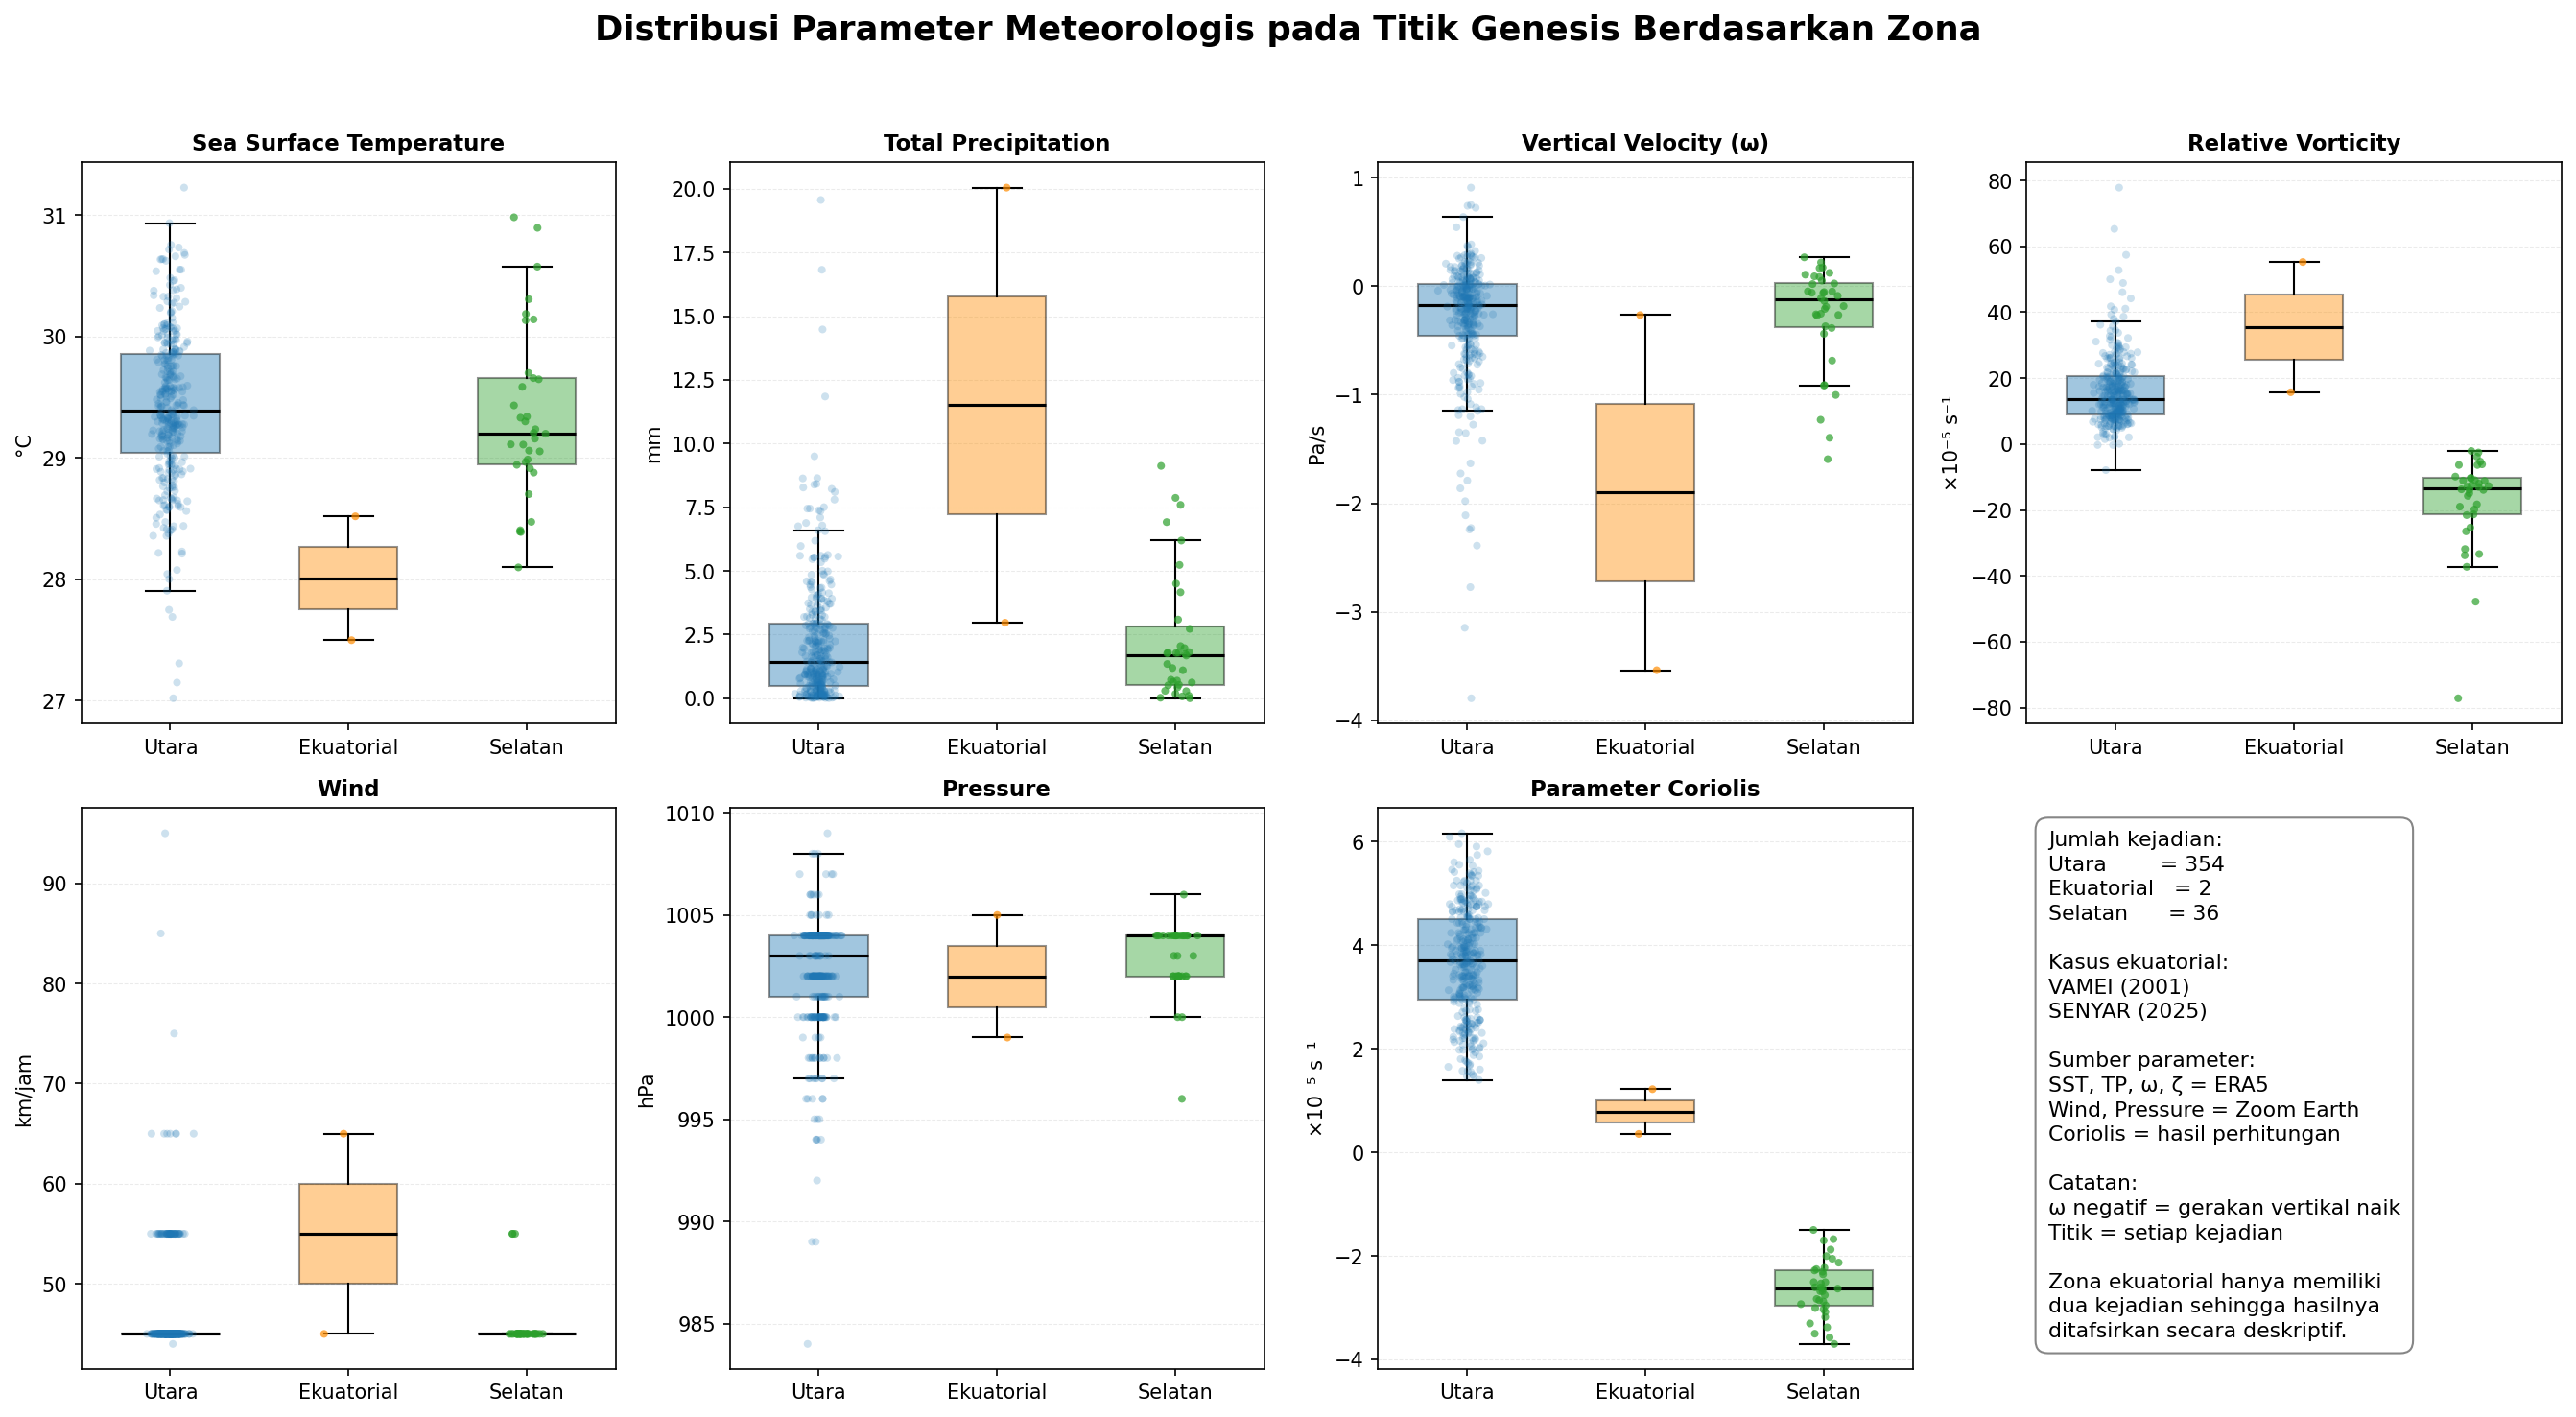


TABEL 3.7
RATA-RATA PARAMETER METEOROLOGIS PADA TITIK GENESIS BERDASARKAN ZONA
      Zona  Jumlah Kejadian  SST (°C)  TP (mm)  ω (Pa/s)  Vortisitas (×10⁻⁵ s⁻¹)  Wind (km/jam)  Pressure (hPa)  Coriolis (×10⁻⁵ s⁻¹)
     Utara              354    29.413    2.197    -0.294                  16.156         47.235        1002.186                 3.677
Ekuatorial                2    28.008   11.506    -1.902                  35.481         55.000        1002.000                 0.788
   Selatan               36    29.338    2.292    -0.273                 -17.901         45.833        1002.917                -2.632

KELENGKAPAN DATA
      Zona                      Parameter  Jumlah Kejadian  N Valid  N Missing  Kelengkapan (%)
     Utara                       SST (°C)              354      350          4            98.87
     Utara       Total Precipitation (mm)              354      354          0           100.00
     Utara    Vertical Velocity, ω (Pa/s)              354      354          0

In [1]:
# ============================================================
# 0. IMPORT LIBRARY
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)


# ============================================================
# 1. PENGATURAN FILE
# ============================================================

FILE_PATH = "Siklon_Tropis_ERA5_Extracted.xlsx"
SHEET_NAME = "Sheet1"

OUTPUT_DIR = "output_3_1_3"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


OUTPUT_EXCEL = os.path.join(
    OUTPUT_DIR,
    "Hasil_3_1_3_1_Meteorologi_Genesis.xlsx"
)


OUTPUT_G39 = os.path.join(
    OUTPUT_DIR,
    "Gambar_3.9_Distribusi_Meteorologi_Genesis.png"
)


# ============================================================
# 2. DOMAIN PENELITIAN
# ============================================================

LON_MIN = 95
LON_MAX = 145

LAT_MIN = -15
LAT_MAX = 25

EQ_MIN = -5
EQ_MAX = 5

YEAR_START = 2001
YEAR_END = 2025


# ============================================================
# 3. URUTAN DAN WARNA ZONA
# ============================================================

ZONE_ORDER = [
    "Utara",
    "Ekuatorial",
    "Selatan"
]


ZONE_COLORS = {
    "Utara": "#1f77b4",
    "Ekuatorial": "#ff8c00",
    "Selatan": "#2ca02c"
}


# ============================================================
# 4. PENGATURAN VISUAL
# ============================================================

plt.rcParams.update({

    "font.family": "DejaVu Sans",

    "font.size": 10,

    "axes.titlesize": 11,

    "axes.labelsize": 10,

    "figure.dpi": 150,

    "savefig.dpi": 300

})


# ============================================================
# 5. MEMBACA DATA
# ============================================================

df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME
)


print("=" * 80)
print("DATA AWAL")
print("=" * 80)

print(
    "Jumlah baris :",
    len(df)
)

print(
    "Jumlah SID   :",
    df["SID"].nunique()
)


# ============================================================
# 6. CLEANING DATA
# ============================================================

df["ISO_TIME"] = pd.to_datetime(
    df["ISO_TIME"],
    errors="coerce"
)


numeric_columns = [

    "LAT",
    "LON",
    "SEASON",

    # Zoom Earth
    "WIND_km/h",
    "PRESSURE_hPa",

    # ERA5
    "era5_sst",
    "era5_tp",
    "era5_w",
    "era5_vo"

]


for col in numeric_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# Hapus baris tanpa data dasar
df = df.dropna(
    subset=[
        "SID",
        "ISO_TIME",
        "LAT",
        "LON"
    ]
).copy()


# Validasi latitude
df = df[
    df["LAT"].between(
        -90,
        90
    )
].copy()


# Validasi longitude
df = df[
    df["LON"].between(
        -180,
        360
    )
].copy()


# Hilangkan pengamatan duplikat
df = df.drop_duplicates(
    subset=[
        "SID",
        "ISO_TIME"
    ],
    keep="first"
)


# Urutkan berdasarkan SID dan waktu
df = df.sort_values(
    [
        "SID",
        "ISO_TIME"
    ]
).reset_index(
    drop=True
)


# ============================================================
# 7. IDENTIFIKASI TITIK GENESIS
# ============================================================
#
# Genesis didefinisikan secara operasional sebagai
# posisi pertama setiap SID setelah pengurutan waktu.
# ============================================================

genesis_all = (

    df.drop_duplicates(
        subset="SID",
        keep="first"
    )

    .copy()

)


# ============================================================
# 8. FILTER PERIODE
# ============================================================

genesis_all = genesis_all[

    genesis_all["SEASON"].between(
        YEAR_START,
        YEAR_END
    )

].copy()


# ============================================================
# 9. FILTER DOMAIN PENELITIAN
# ============================================================

genesis = genesis_all[

    genesis_all["LON"].between(
        LON_MIN,
        LON_MAX,
        inclusive="both"
    )

    &

    genesis_all["LAT"].between(
        LAT_MIN,
        LAT_MAX,
        inclusive="both"
    )

].copy()


# ============================================================
# 10. KLASIFIKASI ZONA
# ============================================================

def classify_zone(lat):

    if EQ_MIN <= lat <= EQ_MAX:

        return "Ekuatorial"

    elif lat > EQ_MAX:

        return "Utara"

    else:

        return "Selatan"


genesis["Zona"] = (

    genesis["LAT"]
    .apply(
        classify_zone
    )

)


# ============================================================
# 11. QUALITY CONTROL POPULASI
# ============================================================

print("\n" + "=" * 80)
print("GENESIS DALAM DOMAIN PENELITIAN")
print("=" * 80)


print(
    "Jumlah kejadian:",
    len(genesis)
)


print("\nJumlah berdasarkan zona:")

print(

    genesis["Zona"]

    .value_counts()

    .reindex(
        ZONE_ORDER,
        fill_value=0
    )

)


# Dataset penelitian yang diharapkan:
#
# Total      = 392
# Utara      = 354
# Ekuatorial = 2
# Selatan    = 36

if len(genesis) != 392:

    print(
        "\nPERINGATAN:"
        "\nJumlah kejadian bukan 392."
        "\nPeriksa kembali file input."
    )


# ============================================================
# 12. KONVERSI PARAMETER ERA5
# ============================================================
#
# SST:
# Kelvin -> Celsius
#
# Total precipitation:
# meter -> milimeter
#
# w:
# tetap Pa/s
#
# vo:
# tetap s^-1,
# kemudian dikalikan 10^5 untuk penyajian
# ============================================================


# ------------------------------------------------------------
# SST
# ------------------------------------------------------------

genesis["SST_C"] = (

    genesis["era5_sst"]

    -

    273.15

)


# ------------------------------------------------------------
# Total Precipitation
# ------------------------------------------------------------

genesis["TP_mm"] = (

    genesis["era5_tp"]

    *

    1000.0

)


# ------------------------------------------------------------
# Vertical Velocity
# ------------------------------------------------------------

genesis["Omega_Pa_s"] = (

    genesis["era5_w"]

)


# ------------------------------------------------------------
# Relative Vorticity
# ------------------------------------------------------------

genesis["Vorticity_s1"] = (

    genesis["era5_vo"]

)


genesis["Vorticity_1e5"] = (

    genesis["Vorticity_s1"]

    *

    1e5

)


# ============================================================
# 13. PARAMETER ZOOM EARTH
# ============================================================
#
# Wind dan Pressure TIDAK dikonversi karena
# dalam dataset sudah menggunakan:
#
# WIND_km/h    -> km/jam
# PRESSURE_hPa -> hPa
# ============================================================

genesis["Wind_kmh"] = (

    genesis["WIND_km/h"]

)


genesis["Pressure_hPa"] = (

    genesis["PRESSURE_hPa"]

)


# ============================================================
# 14. PARAMETER CORIOLIS
# ============================================================
#
# f = 2 * Omega * sin(phi)
#
# Omega = kecepatan sudut rotasi bumi
# phi   = latitude
# ============================================================

OMEGA_EARTH = 7.2921159e-5


genesis["Coriolis_s1"] = (

    2

    *

    OMEGA_EARTH

    *

    np.sin(

        np.radians(
            genesis["LAT"]
        )

    )

)


# Untuk penyajian tabel
genesis["Coriolis_1e5"] = (

    genesis["Coriolis_s1"]

    *

    1e5

)


# ============================================================
# 15. DEFINISI PARAMETER ANALISIS
# ============================================================

PARAMETERS = {

    "SST_C":
        "SST (°C)",

    "TP_mm":
        "Total Precipitation (mm)",

    "Omega_Pa_s":
        "Vertical Velocity, ω (Pa/s)",

    "Vorticity_1e5":
        "Relative Vorticity (×10⁻⁵ s⁻¹)",

    "Wind_kmh":
        "Wind (km/jam)",

    "Pressure_hPa":
        "Pressure (hPa)",

    "Coriolis_1e5":
        "Parameter Coriolis (×10⁻⁵ s⁻¹)"

}


# ============================================================
# 16. QUALITY CONTROL PARAMETER
# ============================================================

print("\n" + "=" * 80)
print("QUALITY CONTROL PARAMETER")
print("=" * 80)


for variable, label in PARAMETERS.items():


    n_valid = (

        genesis[variable]

        .notna()

        .sum()

    )


    n_missing = (

        genesis[variable]

        .isna()

        .sum()

    )


    print(
        f"{label:<42}"
        f"Valid = {n_valid:<4} "
        f"Missing = {n_missing}"
    )


# ============================================================
# 17. QC KELENGKAPAN PER ZONA
# ============================================================

completeness_records = []


for zone in ZONE_ORDER:


    subset = genesis[
        genesis["Zona"]
        ==
        zone
    ]


    for variable, label in PARAMETERS.items():


        n_total = len(
            subset
        )


        n_valid = (

            subset[variable]

            .notna()

            .sum()

        )


        if n_total > 0:

            completeness = (

                n_valid

                /

                n_total

                *

                100

            )

        else:

            completeness = np.nan


        completeness_records.append({

            "Zona":
                zone,

            "Parameter":
                label,

            "Jumlah Kejadian":
                n_total,

            "N Valid":
                n_valid,

            "N Missing":
                n_total - n_valid,

            "Kelengkapan (%)":
                completeness

        })


completeness_df = pd.DataFrame(
    completeness_records
)


# ============================================================
# 18. STATISTIK DESKRIPTIF LENGKAP
# ============================================================

statistics_records = []


for zone in ZONE_ORDER:


    subset = genesis[
        genesis["Zona"]
        ==
        zone
    ]


    for variable, label in PARAMETERS.items():


        values = (

            subset[variable]

            .dropna()

        )


        if len(values) > 0:

            mean_value = (
                values.mean()
            )

            median_value = (
                values.median()
            )

            minimum_value = (
                values.min()
            )

            maximum_value = (
                values.max()
            )


            if len(values) > 1:

                std_value = (
                    values.std()
                )

            else:

                std_value = np.nan


        else:

            mean_value = np.nan
            median_value = np.nan
            minimum_value = np.nan
            maximum_value = np.nan
            std_value = np.nan


        statistics_records.append({

            "Zona":
                zone,

            "Parameter":
                label,

            "N Valid":
                len(values),

            "Rata-rata":
                mean_value,

            "Median":
                median_value,

            "Minimum":
                minimum_value,

            "Maksimum":
                maximum_value,

            "Standar Deviasi":
                std_value

        })


statistics_df = pd.DataFrame(
    statistics_records
)


# ============================================================
# 19. TABEL 3.7
# RATA-RATA PARAMETER METEOROLOGIS PADA TITIK GENESIS
# ============================================================

table_records = []


for zone in ZONE_ORDER:


    subset = genesis[
        genesis["Zona"]
        ==
        zone
    ]


    table_records.append({

        "Zona":
            zone,

        "Jumlah Kejadian":
            len(subset),

        "SST (°C)":
            subset["SST_C"].mean(),

        "TP (mm)":
            subset["TP_mm"].mean(),

        "ω (Pa/s)":
            subset["Omega_Pa_s"].mean(),

        "Vortisitas (×10⁻⁵ s⁻¹)":
            subset["Vorticity_1e5"].mean(),

        "Wind (km/jam)":
            subset["Wind_kmh"].mean(),

        "Pressure (hPa)":
            subset["Pressure_hPa"].mean(),

        "Coriolis (×10⁻⁵ s⁻¹)":
            subset["Coriolis_1e5"].mean()

    })


table_37 = pd.DataFrame(
    table_records
)


# ============================================================
# 20. DATA DUA KEJADIAN EKUATORIAL
# ============================================================
#
# Disimpan sekarang sebagai data pendukung.
#
# Analisis khusus dilakukan nanti pada 3.1.3.4.
# ============================================================

equatorial_cases = genesis[

    genesis["Zona"]
    ==
    "Ekuatorial"

][

    [
        "SID",
        "NAME",
        "SEASON",
        "ISO_TIME",

        "LAT",
        "LON",

        "SST_C",
        "TP_mm",
        "Omega_Pa_s",
        "Vorticity_1e5",

        "Wind_kmh",
        "Pressure_hPa",

        "Coriolis_1e5"
    ]

].copy()


# ============================================================
# 21. CETAK DATA EKUATORIAL
# ============================================================

print("\n" + "=" * 80)
print("KEJADIAN GENESIS ZONA EKUATORIAL")
print("=" * 80)


print(

    equatorial_cases[

        [
            "NAME",
            "SEASON",
            "LAT",
            "LON",
            "Wind_kmh",
            "Pressure_hPa"
        ]

    ]

    .to_string(
        index=False
    )

)


# ============================================================
# 22. SIMPAN EXCEL
# ============================================================

with pd.ExcelWriter(

    OUTPUT_EXCEL,

    engine="openpyxl"

) as writer:


    # --------------------------------------------------------
    # Tabel utama skripsi
    # --------------------------------------------------------

    table_37.round(
        3
    ).to_excel(

        writer,

        sheet_name="Tabel 3.7",

        index=False

    )


    # --------------------------------------------------------
    # Statistik lengkap
    # --------------------------------------------------------

    statistics_df.round(
        4
    ).to_excel(

        writer,

        sheet_name="Statistik Lengkap",

        index=False

    )


    # --------------------------------------------------------
    # Kelengkapan
    # --------------------------------------------------------

    completeness_df.round(
        2
    ).to_excel(

        writer,

        sheet_name="QC Kelengkapan",

        index=False

    )


    # --------------------------------------------------------
    # Dua rare-event ekuatorial
    # --------------------------------------------------------

    equatorial_cases.round(
        4
    ).to_excel(

        writer,

        sheet_name="Kasus Ekuatorial",

        index=False

    )


    # --------------------------------------------------------
    # Seluruh data genesis
    # --------------------------------------------------------

    genesis.to_excel(

        writer,

        sheet_name="Data Genesis",

        index=False

    )


# ============================================================
# 23. FORMAT EXCEL
# ============================================================

wb = load_workbook(
    OUTPUT_EXCEL
)


header_fill = PatternFill(
    "solid",
    fgColor="D9EAF7"
)


header_font = Font(
    bold=True
)


thin_border = Border(

    left=Side(
        style="thin",
        color="BFBFBF"
    ),

    right=Side(
        style="thin",
        color="BFBFBF"
    ),

    top=Side(
        style="thin",
        color="BFBFBF"
    ),

    bottom=Side(
        style="thin",
        color="BFBFBF"
    )

)


for ws in wb.worksheets:


    ws.freeze_panes = "A2"


    # Header
    for cell in ws[1]:


        cell.fill = (
            header_fill
        )


        cell.font = (
            header_font
        )


        cell.alignment = Alignment(

            horizontal="center",

            vertical="center"

        )


    # Isi
    for row in ws.iter_rows():


        for cell in row:


            cell.border = (
                thin_border
            )


            cell.alignment = Alignment(
                vertical="center"
            )


    # Lebar kolom
    for column_cells in ws.columns:


        column_letter = (
            column_cells[0]
            .column_letter
        )


        max_length = 0


        for cell in column_cells:


            if cell.value is not None:


                max_length = max(

                    max_length,

                    len(
                        str(
                            cell.value
                        )
                    )

                )


        ws.column_dimensions[
            column_letter
        ].width = min(

            max_length + 2,

            38

        )


wb.save(
    OUTPUT_EXCEL
)


print(
    "\nExcel berhasil disimpan:"
)

print(
    OUTPUT_EXCEL
)


# ============================================================
# ============================================================
#
#                    GAMBAR 3.9
#
# DISTRIBUSI PARAMETER METEOROLOGIS
# PADA TITIK GENESIS BERDASARKAN ZONA
#
# ============================================================
# ============================================================


# ============================================================
# 24. PARAMETER PLOT
# ============================================================

PLOT_PARAMETERS = [

    (
        "SST_C",
        "Sea Surface Temperature",
        "°C"
    ),

    (
        "TP_mm",
        "Total Precipitation",
        "mm"
    ),

    (
        "Omega_Pa_s",
        "Vertical Velocity (ω)",
        "Pa/s"
    ),

    (
        "Vorticity_1e5",
        "Relative Vorticity",
        "×10⁻⁵ s⁻¹"
    ),

    (
        "Wind_kmh",
        "Wind",
        "km/jam"
    ),

    (
        "Pressure_hPa",
        "Pressure",
        "hPa"
    ),

    (
        "Coriolis_1e5",
        "Parameter Coriolis",
        "×10⁻⁵ s⁻¹"
    )

]


# ============================================================
# 25. BUAT FIGURE
# ============================================================

fig, axes = plt.subplots(

    2,
    4,

    figsize=(
        18,
        10
    )

)


axes = axes.flatten()


# Generator random hanya untuk jitter titik
rng = np.random.default_rng(
    42
)


# ============================================================
# 26. PLOT SETIAP PARAMETER
# ============================================================

for ax, (
    variable,
    title,
    unit
) in zip(

    axes,
    PLOT_PARAMETERS

):


    # --------------------------------------------------------
    # Data per zona
    # --------------------------------------------------------

    data_by_zone = [

        genesis.loc[

            genesis["Zona"]
            ==
            zone,

            variable

        ]

        .dropna()

        .to_numpy()

        for zone in ZONE_ORDER

    ]


    # --------------------------------------------------------
    # BOXPLOT
    # --------------------------------------------------------

    box = ax.boxplot(

        data_by_zone,

        labels=ZONE_ORDER,

        patch_artist=True,

        widths=0.55,

        showfliers=False,

        medianprops=dict(

            color="black",

            linewidth=1.5

        ),

        whiskerprops=dict(

            linewidth=1.0

        ),

        capprops=dict(

            linewidth=1.0

        )

    )


    # --------------------------------------------------------
    # Warna box
    # --------------------------------------------------------

    for patch, zone in zip(

        box["boxes"],
        ZONE_ORDER

    ):


        patch.set_facecolor(

            ZONE_COLORS[
                zone
            ]

        )


        patch.set_alpha(
            0.42
        )


    # --------------------------------------------------------
    # TITIK OBSERVASI INDIVIDUAL
    # --------------------------------------------------------
    #
    # Penting agar dua kasus ekuatorial dapat terlihat
    # secara individual.
    # --------------------------------------------------------

    for x_position, zone in enumerate(

        ZONE_ORDER,

        start=1

    ):


        values = (

            genesis.loc[

                genesis["Zona"]
                ==
                zone,

                variable

            ]

            .dropna()

            .to_numpy()

        )


        jitter = rng.normal(

            loc=0,

            scale=0.045,

            size=len(values)

        )


        # Sampel besar dibuat transparan
        if len(values) > 50:

            point_alpha = 0.22

        else:

            point_alpha = 0.70


        ax.scatter(

            np.full(
                len(values),
                x_position
            )

            +

            jitter,

            values,

            s=15,

            color=ZONE_COLORS[
                zone
            ],

            alpha=point_alpha,

            edgecolors="none",

            zorder=3

        )


    # --------------------------------------------------------
    # Axis
    # --------------------------------------------------------

    ax.set_title(

        title,

        fontweight="bold"

    )


    ax.set_ylabel(
        unit
    )


    ax.grid(

        axis="y",

        linestyle="--",

        linewidth=0.5,

        alpha=0.25

    )


# ============================================================
# 27. PANEL TERAKHIR = INFORMASI
# ============================================================

axes[
    7
].axis(
    "off"
)


info_text = (

    "Jumlah kejadian:\n"
    "Utara        = 354\n"
    "Ekuatorial   = 2\n"
    "Selatan      = 36\n\n"

    "Kasus ekuatorial:\n"
    "VAMEI (2001)\n"
    "SENYAR (2025)\n\n"

    "Sumber parameter:\n"
    "SST, TP, ω, ζ = ERA5\n"
    "Wind, Pressure = Zoom Earth\n"
    "Coriolis = hasil perhitungan\n\n"

    "Catatan:\n"
    "ω negatif = gerakan vertikal naik\n"
    "Titik = setiap kejadian\n\n"

    "Zona ekuatorial hanya memiliki\n"
    "dua kejadian sehingga hasilnya\n"
    "ditafsirkan secara deskriptif."

)


axes[
    7
].text(

    0.04,
    0.96,

    info_text,

    transform=axes[
        7
    ].transAxes,

    va="top",

    fontsize=10.5,

    linespacing=1.35,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        boxstyle="round,pad=0.6",

        alpha=0.95

    )

)


# ============================================================
# 28. JUDUL UTAMA
# ============================================================

fig.suptitle(

    "Distribusi Parameter Meteorologis pada Titik Genesis Berdasarkan Zona",

    fontsize=17,

    fontweight="bold",

    y=0.98

)


# ============================================================
# 29. LAYOUT
# ============================================================

plt.tight_layout(

    rect=[
        0,
        0,
        1,
        0.95
    ]

)


# ============================================================
# 30. SIMPAN GAMBAR
# ============================================================

plt.savefig(

    OUTPUT_G39,

    dpi=300,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


# ============================================================
# 31. HASIL TERMINAL
# ============================================================

print("\n" + "=" * 110)

print(
    "TABEL 3.7"
)

print(
    "RATA-RATA PARAMETER METEOROLOGIS "
    "PADA TITIK GENESIS BERDASARKAN ZONA"
)

print("=" * 110)


print(

    table_37

    .round(3)

    .to_string(
        index=False
    )

)


print("\n" + "=" * 110)

print(
    "KELENGKAPAN DATA"
)

print("=" * 110)


print(

    completeness_df

    .round(2)

    .to_string(
        index=False
    )

)


print(
    "\nSemua output tersimpan di:"
)

print(
    OUTPUT_DIR
)

print("=" * 110)